# AI-Based Crop Disease Detection

## 01 - Dataset Exploration

This notebook explores and analyzes the PlantVillage dataset before model development.

### Objectives
- Handle dataset paths safely across operating systems
- Identify available crop disease classes
- Count images in each class and visualize the distribution
- Examine image dimensions and inspect for corrupt data
- Visualize random sample images across classes


In [6]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("✅ Libraries imported successfully.")


✅ Libraries imported successfully.


In [10]:
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

PLANTVILLAGE_DIR = PROJECT_ROOT.parent / "PlantVillage-Dataset"
COLOR_DATA_DIR = PLANTVILLAGE_DIR / "raw" / "color"

print("Project root:", PROJECT_ROOT)
print("PlantVillage:", PLANTVILLAGE_DIR)
print("Color dataset:", COLOR_DATA_DIR)

Project root: C:\Users\PC\Documents\PythonProjects\crop-disease-detection
PlantVillage: C:\Users\PC\Documents\PythonProjects\PlantVillage-Dataset
Color dataset: C:\Users\PC\Documents\PythonProjects\PlantVillage-Dataset\raw\color


In [11]:
print("Checking PlantVillage dataset...")

if COLOR_DATA_DIR.exists():
    print("✓ PlantVillage color dataset found!")
else:
    print("✗ PlantVillage color dataset NOT found.")
    print("Expected location:", COLOR_DATA_DIR)

Checking PlantVillage dataset...
✓ PlantVillage color dataset found!


In [12]:
class_names = sorted([
    item.name
    for item in COLOR_DATA_DIR.iterdir()
    if item.is_dir()
])

print("Number of classes:", len(class_names))
print()

for number, class_name in enumerate(class_names, start=1):
    print(f"{number}. {class_name}")

Number of classes: 38

1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy
6. Cherry_(including_sour)___Powdery_mildew
7. Cherry_(including_sour)___healthy
8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tomato___Spider_mi

In [13]:
# ============================================
# STEP 5: IDENTIFY DATASET CLASSES
# ============================================

class_names = sorted([
    folder.name
    for folder in COLOR_DATA_DIR.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(class_names))
print()

for number, class_name in enumerate(class_names, start=1):
    print(f"{number}. {class_name}")

Number of classes: 38

1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy
6. Cherry_(including_sour)___Powdery_mildew
7. Cherry_(including_sour)___healthy
8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tomato___Spider_mi

In [14]:
# ============================================
# STEP 6: COUNT IMAGES PER CLASS
# ============================================

from collections import Counter

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

class_image_counts = {}

for class_name in class_names:
    class_dir = COLOR_DATA_DIR / class_name

    image_count = sum(
        1
        for file in class_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    )

    class_image_counts[class_name] = image_count

# Display results
print("IMAGE COUNT PER CLASS")
print("=" * 60)

for class_name, count in class_image_counts.items():
    print(f"{class_name:<55} {count:>5}")

print("=" * 60)
print(f"Total images: {sum(class_image_counts.values())}")
print(f"Total classes: {len(class_image_counts)}")

IMAGE COUNT PER CLASS
Apple___Apple_scab                                        630
Apple___Black_rot                                         621
Apple___Cedar_apple_rust                                  275
Apple___healthy                                          1645
Blueberry___healthy                                      1502
Cherry_(including_sour)___Powdery_mildew                 1052
Cherry_(including_sour)___healthy                         854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot        513
Corn_(maize)___Common_rust_                              1192
Corn_(maize)___Northern_Leaf_Blight                       985
Corn_(maize)___healthy                                   1162
Grape___Black_rot                                        1180
Grape___Esca_(Black_Measles)                             1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)               1076
Grape___healthy                                           423
Orange___Haunglongbing_(Citrus_greening)        

In [15]:
# ============================================
# STEP 7: CHECK CLASS BALANCE
# ============================================

sorted_counts = sorted(
    class_image_counts.items(),
    key=lambda x: x[1]
)

print("SMALLEST CLASSES")
print("=" * 50)

for class_name, count in sorted_counts[:5]:
    print(f"{class_name:<50} {count}")

print()

print("LARGEST CLASSES")
print("=" * 50)

for class_name, count in sorted_counts[-5:]:
    print(f"{class_name:<50} {count}")

SMALLEST CLASSES
Potato___healthy                                   152
Apple___Cedar_apple_rust                           275
Peach___healthy                                    360
Raspberry___healthy                                371
Tomato___Tomato_mosaic_virus                       373

LARGEST CLASSES
Tomato___Bacterial_spot                            2127
Peach___Bacterial_spot                             2297
Soybean___healthy                                  5090
Tomato___Tomato_Yellow_Leaf_Curl_Virus             5357
Orange___Haunglongbing_(Citrus_greening)           5507


In [16]:
# ============================================
# STEP 8: CHECK IMAGE DIMENSIONS
# ============================================

from PIL import Image
from collections import Counter

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

image_sizes = Counter()

# Check up to 5 images from each class
for class_name in class_names:
    class_dir = COLOR_DATA_DIR / class_name

    images_checked = 0

    for file in class_dir.iterdir():
        if (
            file.is_file()
            and file.suffix.lower() in image_extensions
            and images_checked < 5
        ):
            try:
                with Image.open(file) as img:
                    image_sizes[img.size] += 1

                images_checked += 1

            except Exception:
                pass

print("IMAGE DIMENSION CHECK")
print("=" * 60)

for size, count in image_sizes.most_common():
    print(f"{size}: {count} images")

print("=" * 60)
print(f"Different image dimensions found: {len(image_sizes)}")

IMAGE DIMENSION CHECK
(256, 256): 190 images
Different image dimensions found: 1


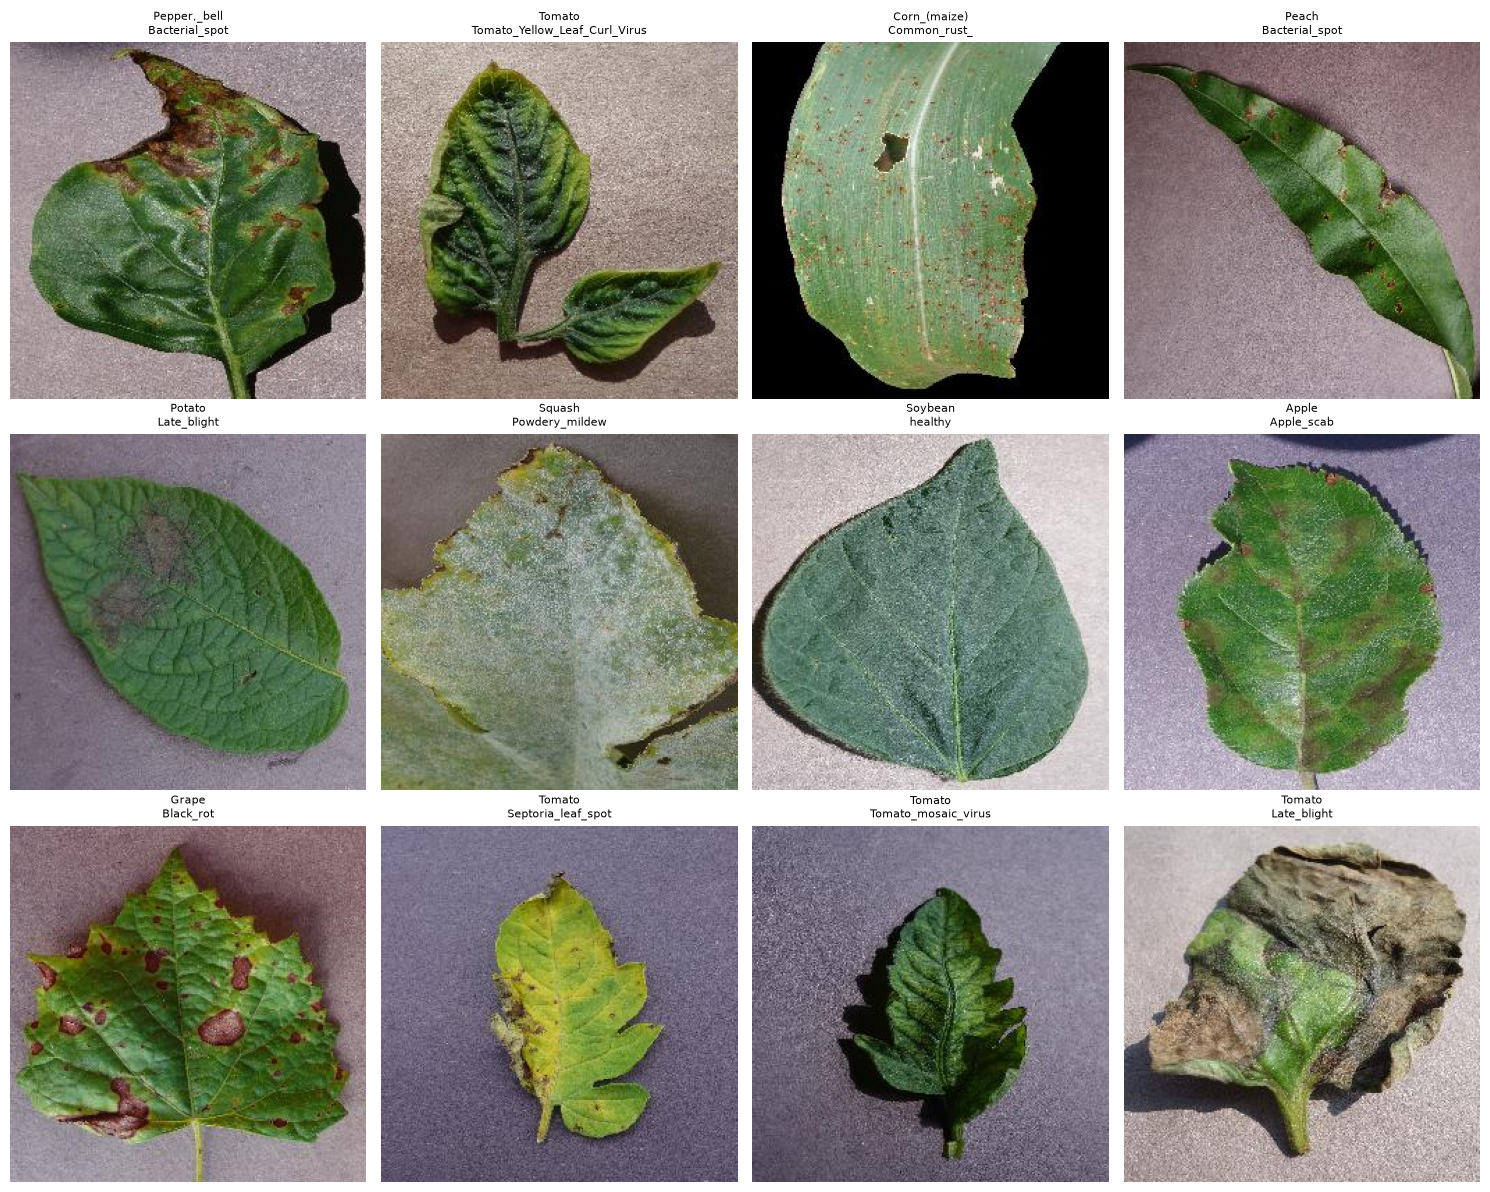

In [17]:
# ============================================
# STEP 9: VISUALIZE SAMPLE IMAGES
# ============================================

import matplotlib.pyplot as plt
import random

# Select 12 random classes
sample_classes = random.sample(class_names, 12)

plt.figure(figsize=(15, 12))

for i, class_name in enumerate(sample_classes):
    class_dir = COLOR_DATA_DIR / class_name

    image_files = [
        file
        for file in class_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    image_file = random.choice(image_files)

    with Image.open(image_file) as img:
        image = img.convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name.replace("___", "\n"), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

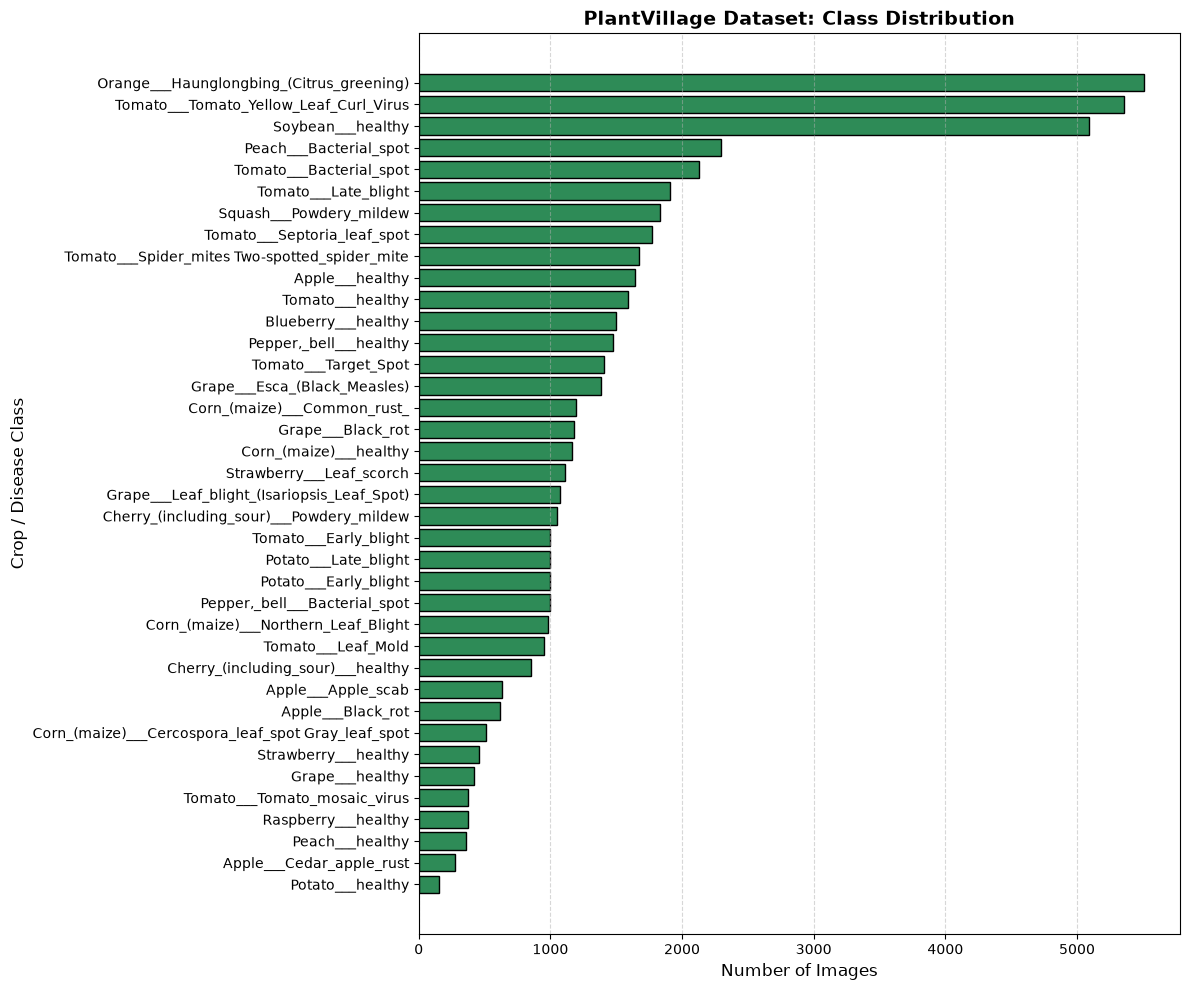

In [18]:
# ============================================
# STEP 10: PLOT CLASS DISTRIBUTION
# ============================================

# Convert dictionary to a DataFrame for clean visualization
df_counts = pd.DataFrame(list(class_image_counts.items()), columns=['Class', 'Count'])
df_counts = df_counts.sort_values(by='Count', ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(df_counts['Class'], df_counts['Count'], color='seagreen', edgecolor='black')
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Crop / Disease Class', fontsize=12)
plt.title('PlantVillage Dataset: Class Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [19]:
# ============================================
# STEP 11: SCAN FOR CORRUPTED IMAGES
# ============================================

corrupted_files = []

print("Scanning all dataset files for corruption (this may take a moment)...")
for class_name in class_names:
    class_dir = COLOR_DATA_DIR / class_name
    for file in class_dir.iterdir():
        if file.is_file() and file.suffix.lower() in image_extensions:
            try:
                with Image.open(file) as img:
                    img.verify() # Fast validation of image data structure
            except Exception as e:
                corrupted_files.append((str(file), str(e)))

print("=" * 60)
if corrupted_files:
    print(f"❌ Found {len(corrupted_files)} corrupted files:")
    for path, err in corrupted_files:
        print(f"- {path} ({err})")
else:
    print("✅ All images verified successfully! No corruption found.")
print("=" * 60)


Scanning all dataset files for corruption (this may take a moment)...
✅ All images verified successfully! No corruption found.
